In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras import Sequential
import warnings
warnings.filterwarnings('ignore')

In [45]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [46]:
X_train.shape

(60000, 28, 28)

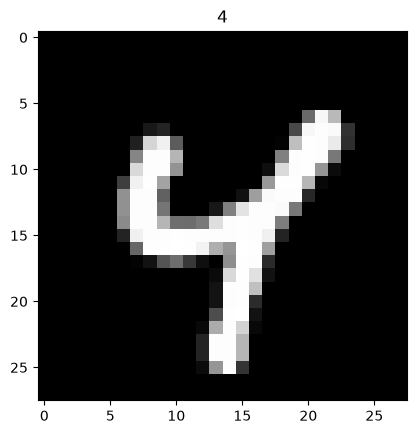

In [47]:
plt.imshow(X_train[1008],cmap='gray')
plt.title(y_train[1008])
plt.show()

In [48]:
X_train[1008]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [49]:
X_train=X_train/255.0
X_test=X_test/255.0

In [50]:
X_train_flattened=X_train.reshape(-1,784)
X_test_flattened=X_test.reshape(-1,784)

In [51]:
model=Sequential([
    Dense(128,activation='relu',input_shape=(784,)),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dropout(0.2), 
    Dense(10,activation='sigmoid')
])

In [52]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [53]:
model.fit(X_train_flattened,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8721 - loss: 0.4271
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9444 - loss: 0.1996
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9557 - loss: 0.1593
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9627 - loss: 0.1347
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9659 - loss: 0.1197


In [55]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9715 - loss: 0.0976


[0.0976293757557869, 0.9714999794960022]

In [56]:
y_predict=model.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [57]:
y_predict[0]

array([8.3644351e-05, 4.0173620e-02, 8.3388197e-01, 2.4404430e-01,
       2.5419008e-03, 1.2599780e-03, 3.2738343e-09, 9.9999970e-01,
       5.7522568e-04, 6.4933968e-01], dtype=float32)

In [58]:
print(np.argmax(y_predict[0]))

7


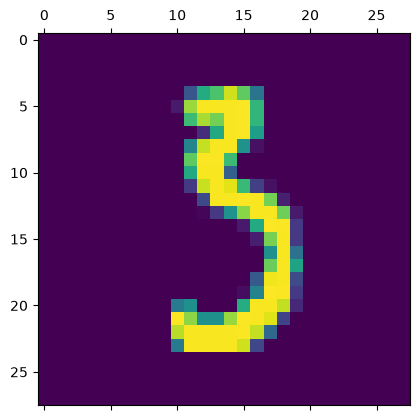

In [61]:
plt.matshow(X_test[1290])

In [62]:
model.save('digit_recognization_model.keras')